<a href="https://colab.research.google.com/github/Sodabeh-Taherpanah/ML-examples/blob/main/AI_ASSESment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Loading and Merging Datasets

save file in my google drive. it is not necessary.

In [ ]:
import kagglehub
import os
import shutil

import os

# Path returned by KaggleHub
dataset_folder = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# List files inside the downloaded dataset folder
for root, dirs, files in os.walk(dataset_folder):
    for file in files:
        print(os.path.join(root, file))  # Print full file paths




100%|██████████| 42.6M/42.6M [00:00<00:00, 126MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/product_category_name_translation.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_sellers_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_geolocation_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_payments_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_orders_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_reviews_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_items_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_products_dataset.csv
/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_customers_dataset.csv


In [ ]:
import pandas as pd

# Load the datasets
orders = pd.read_csv('/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_orders_dataset.csv')
order_items = pd.read_csv('/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_items_dataset.csv')
customers = pd.read_csv('/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_customers_dataset.csv')
products=pd.read_csv('/root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_products_dataset.csv')
# print(products.columns)
print(order_items.columns)
# Display the first few rows to understand the structure
print(orders.head())
print(order_items.head())
print(customers.head())

# Merge order_items with orders on 'order_id'
merged_data = pd.merge(order_items, orders, on='order_id', how='left')

# Merge with products to get category information
merged_data = pd.merge(merged_data, products[['product_id', 'product_category_name']], on='product_id', how='left')



# Merge with customers on 'customer_id'
merged_data = pd.merge(merged_data, customers, on='customer_id', how='left')

# Rename 'order_item_id' to 'quantity' (if it represents quantity)
merged_data.rename(columns={'order_item_id': 'quantity'}, inplace=True)

# Display merged data summary
print(merged_data.info())
print(merged_data.head())


# Display the first few rows of the merged dataset
print(merged_data.head())

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date ord

# Data Preprocessing Steps

Handling Missing Data

We'll start by checking for any missing data and decide how to handle it. We'll handle missing values in critical columns like order_status and product_category_name.

In [ ]:
# Check for missing values
print(merged_data.isnull().sum())

# Handle missing data
# For 'order_status', we can drop rows where this is missing, since it is critical
merged_data = merged_data.dropna(subset=['order_status'])

# For 'product_category_name', we'll fill missing values with 'Unknown' as it's not essential to lose the row
merged_data['product_category_name'].fillna('Unknown', inplace=True)

# If there are missing values in geolocation or other non-critical columns, we can either drop or impute them
merged_data['customer_zip_code_prefix'].fillna(0, inplace=True)

# Check again after handling missing data
print(merged_data.isnull().sum())
print(merged_data.head())


order_id                            0
quantity                            0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
product_category_name            1603
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64
order_id                            0
quantity                            0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0

<ipython-input-113-6dff4b48fbfb>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['product_category_name'].fillna('Unknown', inplace=True)
<ipython-input-113-6dff4b48fbfb>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
# Convert the order purchase timestamp to datetime format
merged_data['order_purchase_timestamp'] = pd.to_datetime(merged_data['order_purchase_timestamp'])

# Check the updated datatype
print(merged_data['order_purchase_timestamp'].dtype)


datetime64[ns]


we'll create a column to determine whether a customer is new or returning based on the number of orders they've made.

In [ ]:
# Count the number of orders for each customer
customer_order_count = merged_data['customer_id'].value_counts()

# Mark customers as new or returning based on the number of orders
merged_data['customer_type'] = merged_data['customer_id'].map(lambda x: 'new' if customer_order_count[x] == 1 else 'returning')

# Display the first few rows to verify
print(merged_data[['customer_id', 'customer_type']].head())


                        customer_id customer_type
0  3ce436f183e68e07877b285a838db11a           new
1  f6dd3ec061db4e3987629fe6b26e5cce           new
2  6489ae5e4333f3693df5ad4372dab6d3           new
3  d4eb9395c8c0431ee92fce09860c5a06           new
4  58dbd0b2d70206bf40e62cd34e84d795           new




```
# This is formatted as code
```

# Question1: new Customers

Answering the Business Question: "How does user behavior of  new  customers?"

the following metrics:

    Order frequency: check for count of new customers then calculate Order frequency per new customer & Top 10 Product Categories by Number of Orders of new customers.

    Average order value: How much do new vs. returning customers spend per order?
    
    Product preferences: Do new vs. returning customers purchase different product categories?



```
# This is formatted as code
```

## Order frequency:

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Count the number of unique orders per customer
order_frequency = merged_data.groupby('customer_id')['order_id'].nunique()

# Convert to dictionary for safe lookup
customer_order_dict = order_frequency.to_dict()

# Step 2: Define customer type safely using `.get()` to avoid KeyError. #.get(x, 1) ensures missing customer IDs default to New, preventing KeyError.
merged_data['customer_type'] = merged_data['customer_id'].map(lambda x: 'Returning' if customer_order_dict.get(x, 1) > 1 else 'New')

# Display counts
print(merged_data['customer_type'].value_counts())





customer_type
New    112650
Name: count, dtype: int64


In [ ]:
# Calculate the number of unique orders for each customer
order_frequency = merged_data.groupby('customer_id')['order_id'].nunique()

# Display the order frequency comparison for new customers
print("Order frequency per customer (since all are new):")
print(order_frequency.describe())


Order frequency per customer (since all are new):
count    98666.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_id, dtype: float64


In [ ]:
import pandas as pd

# Function to calculate the most popular product categories
def product_preferences(df):
    # Count the number of orders per product category
    product_category_counts = df['product_category_name'].value_counts()

    # Display the top product categories
    print("Top Product Categories by Number of Orders:")
    print(product_category_counts.head(10))  # Display top 10 categories

# Call the function
product_preferences(merged_data)

Top Product Categories by Number of Orders:
product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64


Top 10 Product Categories by Number of **Orders** **bold text**

<ipython-input-102-bbb5c4d4027f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_category_counts.index, y=product_category_counts.values, palette='viridis')


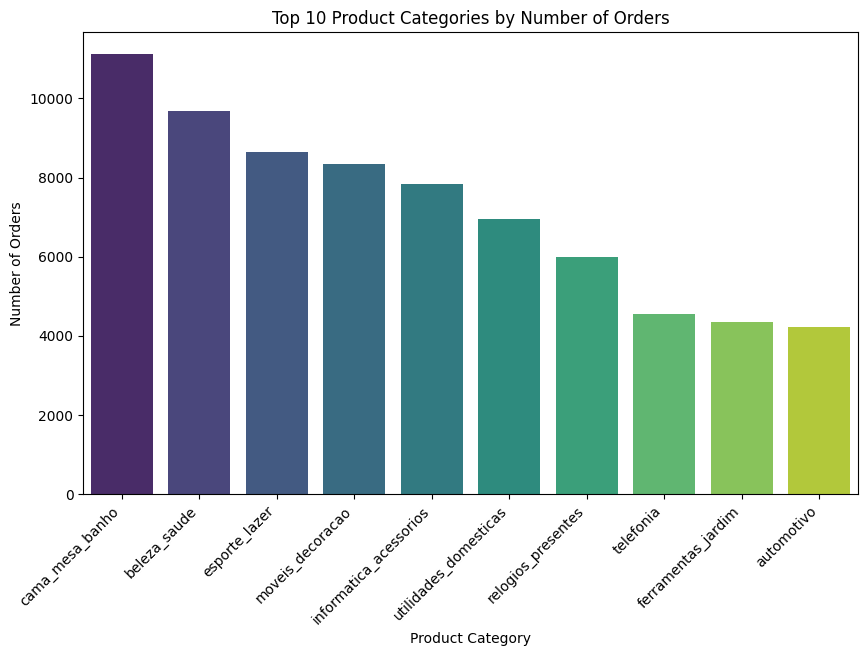

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_product_distribution(df):
    # Count the number of orders per product category
    product_category_counts = df['product_category_name'].value_counts().head(10)  # Top 10 categories

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=product_category_counts.index, y=product_category_counts.values, palette='viridis')
    plt.title('Top 10 Product Categories by Number of Orders')
    plt.xlabel('Product Category')
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Call the function to visualize the product distribution
visualize_product_distribution(merged_data)


## Average order value:



calculated the Average Order Value (AOV) for the "New" customer type, which is approximately 136.69
The total order value is calculated by multiplying the quantity by the price.

In [ ]:
def average_order_value(df):
    # Calculate order value (price * quantity)
    df['order_value'] = df['price'] * df['quantity']

    # Calculate the average order value
    avg_order_value = df.groupby('customer_type')['order_value'].mean()

    # Display the average order value for new customers
    print("Average Order Value per Customer Type:")
    print(avg_order_value)

# Call the function
average_order_value(merged_data)



Average Order Value per Customer Type:
customer_type
New    136.686539
Name: order_value, dtype: float64


## Number of Orders per Hours/Days

In [ ]:
# Function to extract time-based trends
def time_based_trends(df):
    # Convert 'order_purchase_timestamp' to datetime
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

    # Extract hour of the day and day of the week from the timestamp
    df['hour_of_day'] = df['order_purchase_timestamp'].dt.hour
    df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

    # Plot the number of orders by hour of day
    hour_counts = df['hour_of_day'].value_counts().sort_index()
    print("Number of Orders per Hour of the Day:")
    print(hour_counts)

    # Plot the number of orders by day of the week
    day_counts = df['day_of_week'].value_counts().sort_index()
    print("Number of Orders per Day of the Week:")
    print(day_counts)

# Call the function
time_based_trends(merged_data)


Number of Orders per Hour of the Day:
hour_of_day
0     2717
1     1289
2      584
3      314
4      244
5      218
6      556
7     1377
8     3377
9     5449
10    7034
11    7432
12    6819
13    7403
14    7565
15    7370
16    7653
17    7010
18    6550
19    6716
20    6875
21    6920
22    6541
23    4637
Name: count, dtype: int64
Number of Orders per Day of the Week:
day_of_week
Friday       16039
Monday       18393
Saturday     12168
Sunday       13416
Thursday     16797
Tuesday      18237
Wednesday    17600
Name: count, dtype: int64


Number of Orders per Hour of the Day:
hour_of_day
0     2717
1     1289
2      584
3      314
4      244
5      218
6      556
7     1377
8     3377
9     5449
10    7034
11    7432
12    6819
13    7403
14    7565
15    7370
16    7653
17    7010
18    6550
19    6716
20    6875
21    6920
22    6541
23    4637
Name: count, dtype: int64
Number of Orders per Day of the Week:
day_of_week
Friday       16039
Monday       18393
Saturday     12168
Sunday       13416
Thursday     16797
Tuesday      18237
Wednesday    17600
Name: count, dtype: int64


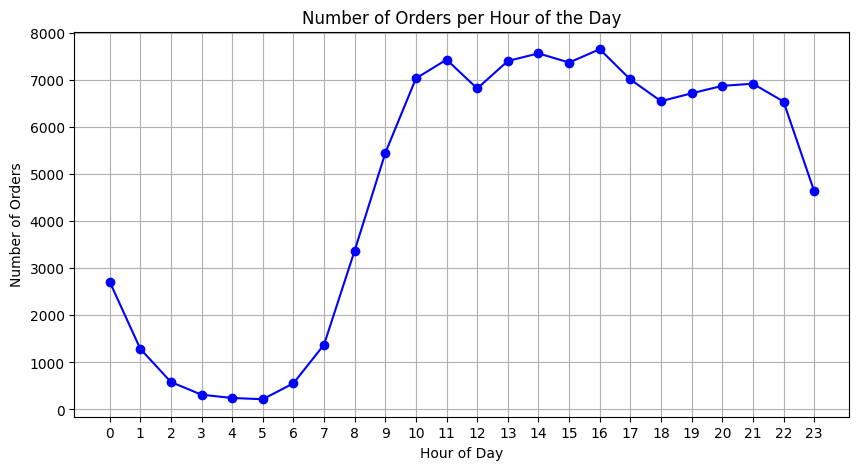

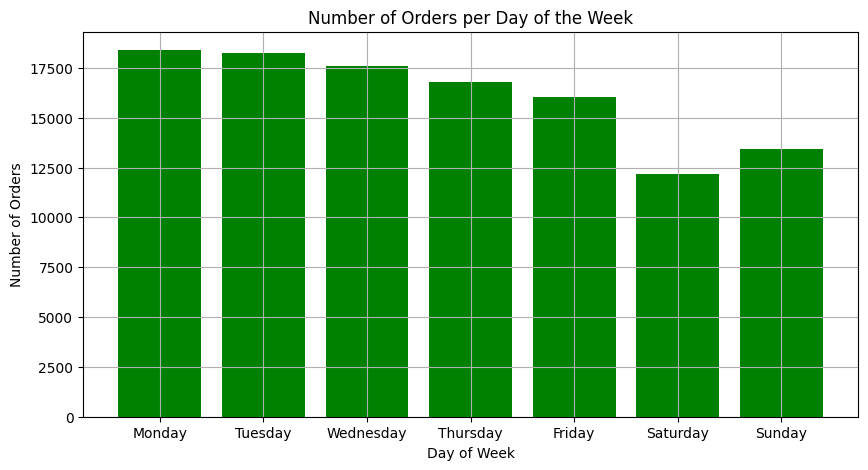

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to extract time-based trends
def time_based_trends(df):
    # Convert 'order_purchase_timestamp' to datetime
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

    # Extract hour of the day and day of the week from the timestamp
    df['hour_of_day'] = df['order_purchase_timestamp'].dt.hour
    df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

    # Number of Orders per Hour of the Day
    hour_counts = df['hour_of_day'].value_counts().sort_index()
    print("Number of Orders per Hour of the Day:")
    print(hour_counts)

    # Number of Orders per Day of the Week
    day_counts = df['day_of_week'].value_counts().sort_index()
    print("Number of Orders per Day of the Week:")
    print(day_counts)

    # Visualizing the results with plots
    # Plot for Hour of Day
    plt.figure(figsize=(10, 5))
    plt.plot(hour_counts.index, hour_counts.values, marker='o', color='b')
    plt.title('Number of Orders per Hour of the Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Orders')
    plt.grid(True)
    plt.xticks(range(24))  # Show all 24 hours
    plt.show()

    # Plot for Day of Week
    plt.figure(figsize=(10, 5))
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = day_counts[day_order]  # Reorder days to start with Monday
    plt.bar(day_counts.index, day_counts.values, color='g')
    plt.title('Number of Orders per Day of the Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Number of Orders')
    plt.grid(True)
    plt.show()

# Assuming 'merged_data' is your dataset
time_based_trends(merged_data)


# Question 2: What product categories have the highest conversion rates?

By grouping the data by product_category_name, we calculate how many orders were completed and then compute the conversion rate for each product category.

In [ ]:


# Check if 'product_category_name' exists in merged_data and merge if necessary
if 'product_category_name' not in merged_data.columns:
    merged_data = pd.merge(
        merged_data,
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )

# Display the columns after the merge
print(merged_data.columns.tolist())  # Should now include 'product_category_name'

# Group by product category and calculate total orders and completed orders
category_conversion = merged_data.groupby('product_category_name').agg(
    total_orders=('order_id', 'nunique'),
    completed_orders=('order_status', lambda x: (x == 'delivered').sum())
)

# Add a new column for conversion rate
category_conversion['conversion_rate'] = category_conversion['completed_orders'] / category_conversion['total_orders']

# Sort by conversion_rate in descending order
category_conversion = category_conversion.sort_values(by='conversion_rate', ascending=False)

# Show the top 5 categories with the highest conversion rates using slicing
print("Top 5 product categories with the highest conversion rates:")
print(category_conversion.head())

# Further manipulations: Tuple unpacking and sorting based on total orders
# Here, I'm creating a tuple of product category and conversion rate and sorting it by conversion rate
category_conversion_tuples = [
    (category, conversion_rate['conversion_rate'])
    for category, conversion_rate in category_conversion.iterrows()
]

# Sorting by conversion_rate (descending)
category_conversion_tuples.sort(key=lambda x: x[1], reverse=True)

# Printing the sorted tuples (product category, conversion rate)
print("\nSorted tuples (product category, conversion rate):")
print(category_conversion_tuples[:5])  # Show the top 5

# Additional feature: Split the data into categories with high and low conversion rates
# Assume categories with conversion_rate > 0.1 are high-conversion categories
high_conversion = category_conversion[category_conversion['conversion_rate'] > 0.1]
low_conversion = category_conversion[category_conversion['conversion_rate'] <= 0.1]

# Display high-conversion and low-conversion categories
print("\nHigh-conversion categories:")
print(high_conversion[['conversion_rate']].head())

print("\nLow-conversion categories:")
print(low_conversion[['conversion_rate']].head())




['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'product_category_name_x', 'product_category_name_y', 'product_category_name']
Top 5 product categories with the highest conversion rates:
                         total_orders  completed_orders  conversion_rate
product_category_name                                                   
sinalizacao_e_seguranca           140               197         1.407143
fraldas_higiene                    27                37         1.370370
moveis_escritorio                1273              1668         1.310291
moveis_decoracao                 6449              8160         1.265312
casa_conforto_2                    24                30         1.250000

Sorted tuples (product category, conversion rate):
[('sinalizacao

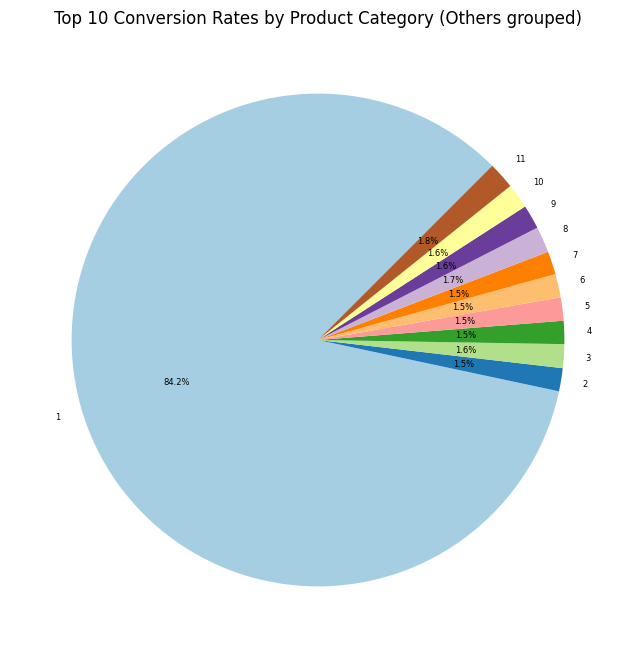


Summary Table with Numeric Labels and Conversion Rates:
                                   Index  Conversion Rate
category_grouped                                         
Other                                  1            67.51
bebidas                                2             1.22
casa_conforto_2                        3             1.25
casa_construcao                        4             1.22
construcao_ferramentas_construcao      5             1.22
construcao_ferramentas_iluminacao      6             1.23
ferramentas_jardim                     7             1.21
fraldas_higiene                        8             1.37
moveis_decoracao                       9             1.27
moveis_escritorio                     10             1.31
sinalizacao_e_seguranca               11             1.41


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'category_conversion' contains the conversion rates calculated earlier

# Display the top 10 categories and their conversion rates
top_categories = category_conversion['conversion_rate'].nlargest(10).index

# Filter out the small categories and label them as 'Other'
category_conversion['category_grouped'] = category_conversion.index.where(
    category_conversion.index.isin(top_categories), 'Other'
)

# Now, aggregate the data to group the 'Other' category
category_grouped = category_conversion.groupby('category_grouped').sum()

# Create labels in the format '1., 2., ...'
labels = [f"{i+1}" for i, rate in enumerate(category_grouped['conversion_rate'])]

# Get a list of colors using a colormap (you can change the colormap to your preference)
colors = plt.cm.Paired(np.linspace(0, 1, len(category_grouped)))

# Plot Pie Chart for the grouped conversion rates with numeric labels
fig, ax = plt.subplots(figsize=(8, 8))

# Creating the pie chart with labels formatted as '1., 2., ... - ConversionRate'
ax.pie(category_grouped['conversion_rate'], labels=labels,
       autopct='%1.1f%%', startangle=45, colors=colors,
       textprops={'fontsize': 6, 'horizontalalignment': 'center'})  # Adjust fontsize and alignment

# Set the title
plt.title('Top 10 Conversion Rates by Product Category (Others grouped)')

# Display the pie chart
plt.show()

# Optionally, display the full table with numeric labels and conversion rates
print("\nSummary Table with Numeric Labels and Conversion Rates:")
table_data = pd.DataFrame({
    'Index': range(1, len(category_grouped) + 1),
    'Conversion Rate': category_grouped['conversion_rate'].round(2)
})
print(table_data)


In [ ]:
styled_df = category_conversion.style.highlight_max(axis=0, color='lightgreen').background_gradient(cmap='YlGnBu', axis=0)
styled_df


,total_orders,completed_orders,conversion_rate
product_category_name,,,
sinalizacao_e_seguranca,140,197,1.407143
fraldas_higiene,27,37,1.370370
moveis_escritorio,1273,1668,1.310291
moveis_decoracao,6449,8160,1.265312
casa_conforto_2,24,30,1.250000
construcao_ferramentas_iluminacao,244,301,1.233607
construcao_ferramentas_construcao,748,916,1.224599
casa_construcao,490,596,1.216327
bebidas,297,361,1.215488
